Using Colab cache for faster access to the 'bank-customer-churn-prediction' dataset.
Dataset Shape: (10000, 14)
Imbalance Ratio: 3.9091801669121256
ROC-AUC: 0.8488133742371031

Default Threshold:

              precision    recall  f1-score   support

           0       0.91      0.88      0.89      1593
           1       0.58      0.68      0.62       407

    accuracy                           0.83      2000
   macro avg       0.75      0.78      0.76      2000
weighted avg       0.85      0.83      0.84      2000

Best Threshold: 0.5500000000000002

Optimized Results:

              precision    recall  f1-score   support

           0       0.91      0.90      0.90      1593
           1       0.61      0.65      0.63       407

    accuracy                           0.85      2000
   macro avg       0.76      0.77      0.77      2000
weighted avg       0.85      0.85      0.85      2000



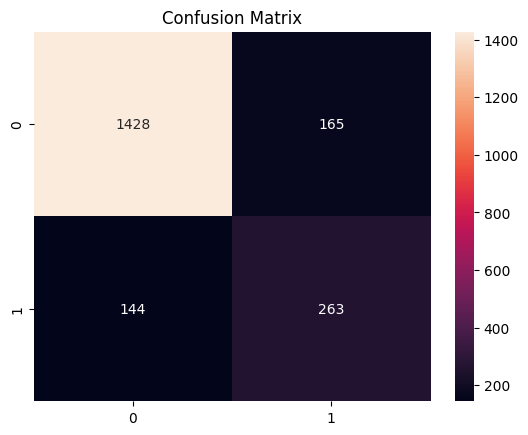

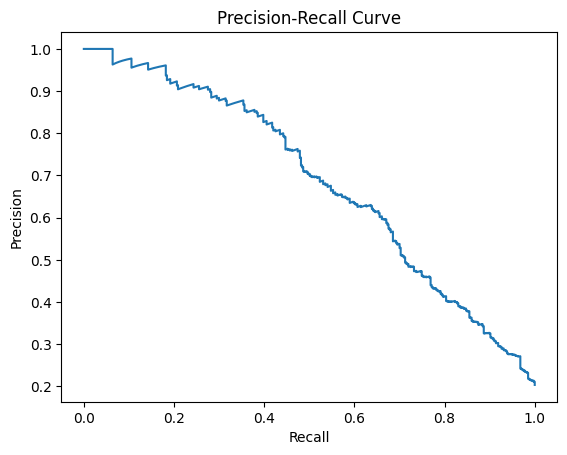

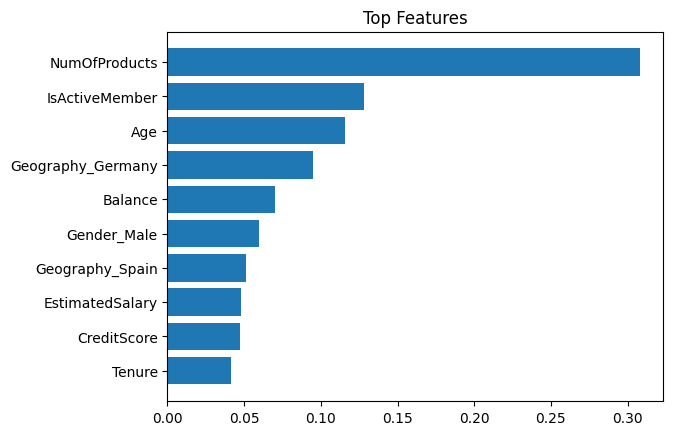


Model saved successfully!


In [6]:
# =========================
# 🚀 FINAL CHURN MODEL (100% COMPATIBLE VERSION)
# =========================

# Install dependencies (force latest stable)
!pip install -U kagglehub xgboost -q

# =========================
# 📥 1. LOAD DATASET
# =========================
import kagglehub
import os
import pandas as pd

path = kagglehub.dataset_download("shantanudhakadd/bank-customer-churn-prediction")
file_path = os.path.join(path, os.listdir(path)[0])

df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)

# =========================
# 🧹 2. CLEAN DATA
# =========================
drop_cols = ['RowNumber', 'CustomerId', 'Surname']
for col in drop_cols:
    if col in df.columns:
        df.drop(columns=col, inplace=True)

# Encode categorical
df = pd.get_dummies(df, drop_first=True)

# =========================
# 🎯 3. TARGET
# =========================
y = df['Exited']
X = df.drop(columns=['Exited'])

# =========================
# ⚖️ 4. HANDLE IMBALANCE
# =========================
neg, pos = y.value_counts()
scale_pos_weight = neg / pos

print("Imbalance Ratio:", scale_pos_weight)

# =========================
# ✂️ 5. SPLIT
# =========================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# 🤖 6. TRAIN MODEL (SAFE VERSION)
# =========================
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    n_jobs=-1
)

# 🚀 NO early stopping (to avoid version errors)
model.fit(X_train, y_train)

# =========================
# 📊 7. EVALUATION
# =========================
from sklearn.metrics import roc_auc_score, classification_report

y_probs = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print("ROC-AUC:", roc_auc_score(y_test, y_probs))

print("\nDefault Threshold:\n")
print(classification_report(y_test, y_pred))

# =========================
# 🎯 8. THRESHOLD TUNING
# =========================
import numpy as np
from sklearn.metrics import f1_score

best_thresh = 0.5
best_f1 = 0

for t in np.arange(0.1, 0.9, 0.05):
    preds = (y_probs > t).astype(int)
    score = f1_score(y_test, preds)

    if score > best_f1:
        best_f1 = score
        best_thresh = t

print("Best Threshold:", best_thresh)

y_pred_opt = (y_probs > best_thresh).astype(int)

print("\nOptimized Results:\n")
print(classification_report(y_test, y_pred_opt))

# =========================
# 📉 9. CONFUSION MATRIX
# =========================
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_opt)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# =========================
# 📈 10. PRECISION-RECALL CURVE
# =========================
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

# =========================
# 🔍 11. FEATURE IMPORTANCE
# =========================
import numpy as np

importances = model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure()
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.title("Top Features")
plt.show()

# =========================
# 💾 12. SAVE MODEL
# =========================
import joblib

joblib.dump(model, "final_churn_model.pkl")

print("\nModel saved successfully!")